# Food Demand Forecasting Project

### Week-1

In [1]:
## Importing Libraries
%pip install pandas matplotlib seaborn numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
## Loading Dataset
df = pd.read_csv('C:\\Users\\vaide\\OneDrive\\Documents\\GitHub\\ai-grievance-system\\data\\train.csv')
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 31.3 MB


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
count,4.565480e+05,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000,456548.000000
mean,1.250096e+06,74.768771,82.105796,2024.337458,332.238933,354.156627,0.081152,0.10920,261.872760
std,1.443548e+05,41.524956,45.975046,547.420920,152.939723,160.715914,0.273069,0.31189,395.922798
min,1.000000e+06,1.000000,10.000000,1062.000000,2.970000,55.350000,0.000000,0.00000,13.000000
25%,1.124999e+06,39.000000,43.000000,1558.000000,228.950000,243.500000,0.000000,0.00000,54.000000
50%,1.250184e+06,76.000000,76.000000,1993.000000,296.820000,310.460000,0.000000,0.00000,136.000000
75%,1.375140e+06,111.000000,110.000000,2539.000000,445.230000,458.870000,0.000000,0.00000,324.000000
max,1.499999e+06,145.000000,186.000000,2956.000000,866.270000,866.270000,1.000000,1.00000,24299.000000


In [4]:
## Converting date column
df['week'] = pd.to_datetime(df['week'])
df = df.sort_values('week')

### EDA

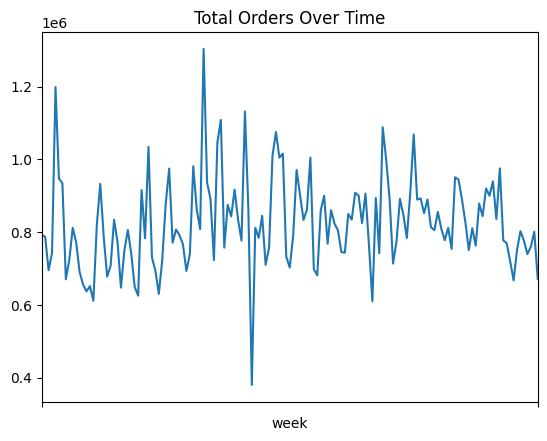

In [5]:
## Sales Trend Over TIme
plt.figure()
df.groupby('week')['num_orders'].sum().plot()
plt.title("Total Orders Over Time")
plt.show()

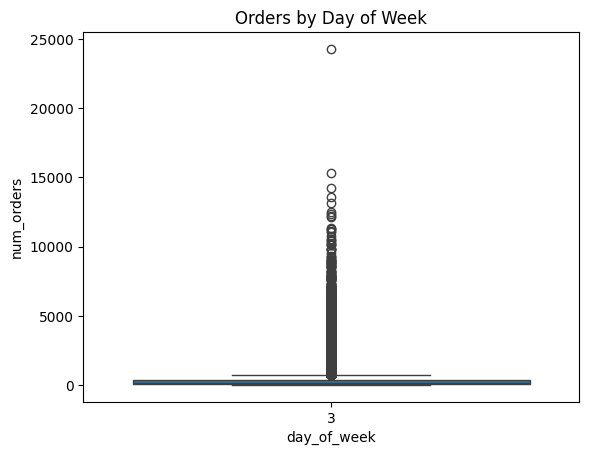

In [7]:
## Orders by Day of Week
df['day_of_week'] = df['week'].dt.dayofweek
sns.boxplot(x='day_of_week', y='num_orders', data=df)
plt.title("Orders by Day of Week")
plt.show()

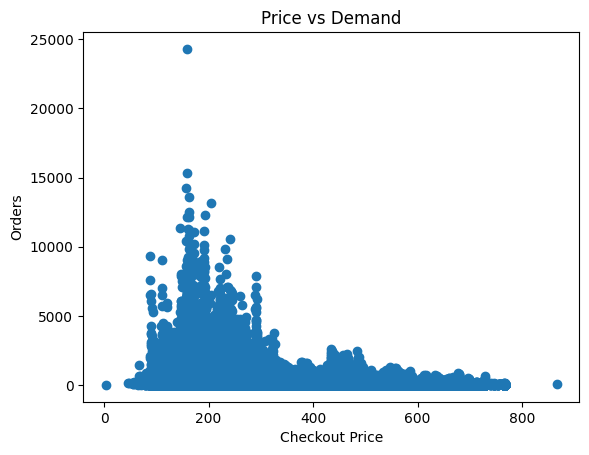

In [8]:
## Price Vs Demand
plt.scatter(df['checkout_price'], df['num_orders'])
plt.xlabel("Checkout Price")
plt.ylabel("Orders")
plt.title("Price vs Demand")
plt.show()

## Week-2

### Feature Engineering

In [12]:
df['month'] = df['week'].dt.month
df['week_of_year'] = df['week'].dt.isocalendar().week.astype(int)
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

df['lag_7'] = df['num_orders'].shift(7)
df['lag_14'] = df['num_orders'].shift(14)

df['rolling_mean_7'] = df['num_orders'].rolling(7).mean()

df.dropna(inplace=True)

df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,day_of_week,month,week_of_year,is_weekend,lag_7,lag_14,rolling_mean_7
1925,1302652,1970-01-01 00:00:00.000000001,72,2126,487.00,532.53,0,1,26,3,1,1,0,96.0,175.0,247.714286
1926,1072541,1970-01-01 00:00:00.000000001,72,2826,328.83,328.83,0,0,420,3,1,1,0,339.0,432.0,259.285714
1927,1086872,1970-01-01 00:00:00.000000001,72,1754,284.27,284.27,0,0,528,3,1,1,0,1108.0,730.0,176.428571
1928,1105438,1970-01-01 00:00:00.000000001,72,1971,263.90,322.04,1,1,999,3,1,1,0,69.0,865.0,309.285714
1929,1246222,1970-01-01 00:00:00.000000001,72,1902,389.03,445.23,0,0,14,3,1,1,0,41.0,998.0,305.428571


In [ ]:
## Preparing Features
features = ['day_of_week','month','week_of_year','is_weekend',
            'lag_7','lag_14','rolling_mean_7']

X = df[features]
y = df['num_orders']

In [14]:
X.head()

,day_of_week,month,week_of_year,is_weekend,lag_7,lag_14,rolling_mean_7
1956,3,1,1,0,136.0,177.0,233.000000
1957,3,1,1,0,53.0,80.0,287.142857
1958,3,1,1,0,107.0,82.0,376.142857
1959,3,1,1,0,26.0,13.0,496.000000
1960,3,1,1,0,555.0,1958.0,559.285714


In [15]:
y.head()

1956    175
1957    432
1958    730
1959    865
1960    998
Name: num_orders, dtype: int64

In [11]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
